In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv(r'/kaggle/input/fifa-21-messy-raw-dataset-for-cleaning-exploring/fifa21_opensource.csv')
data

/tmp/ipykernel_17/2988040566.py:1: DtypeWarning: Columns (76) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(r'/kaggle/input/fifa-21-messy-raw-dataset-for-cleaning-exploring/fifa21_opensource.csv')


,photoUrl,LongName,playerUrl,Nationality,Positions,Name,Age,↓OVA,POT,Team & Contract,...,A/W,D/W,IR,PAC,SHO,PAS,DRI,DEF,PHY,Hits
0,https://cdn.sofifa.com/players/158/023/21_60.png,Lionel Messi,http://sofifa.com/player/158023/lionel-messi/2...,Argentina,RW ST CF,L. Messi,33,93,93,\n\n\n\nFC Barcelona\n2004 ~ 2021\n\n,...,Medium,Low,5 ★,85,92,91,95,38,65,\n372
1,https://cdn.sofifa.com/players/020/801/21_60.png,C. Ronaldo dos Santos Aveiro,http://sofifa.com/player/20801/c-ronaldo-dos-s...,Portugal,ST LW,Cristiano Ronaldo,35,92,92,\n\n\n\nJuventus\n2018 ~ 2022\n\n,...,High,Low,5 ★,89,93,81,89,35,77,\n344
2,https://cdn.sofifa.com/players/200/389/21_60.png,Jan Oblak,http://sofifa.com/player/200389/jan-oblak/210005/,Slovenia,GK,J. Oblak,27,91,93,\n\n\n\nAtlético Madrid\n2014 ~ 2023\n\n,...,Medium,Medium,3 ★,87,92,78,90,52,90,\n86
3,https://cdn.sofifa.com/players/192/985/21_60.png,Kevin De Bruyne,http://sofifa.com/player/192985/kevin-de-bruyn...,Belgium,CAM CM,K. De Bruyne,29,91,91,\n\n\n\nManchester City\n2015 ~ 2023\n\n,...,High,High,4 ★,76,86,93,88,64,78,\n163
4,https://cdn.sofifa.com/players/190/871/21_60.png,Neymar da Silva Santos Jr.,http://sofifa.com/player/190871/neymar-da-silv...,Brazil,LW CAM,Neymar Jr,28,91,91,\n\n\n\nParis Saint-Germain\n2017 ~ 2022\n\n,...,High,Medium,5 ★,91,85,86,94,36,59,\n273
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18974,https://cdn.sofifa.com/players/257/710/21_60.png,Mengxuan Zhang,http://sofifa.com/player/257710/mengxuan-zhang...,China PR,CB,Zhang Mengxuan,21,47,52,\n\n\n\nChongqing Dangdai Lifan FC SWM Team\n2...,...,Low,Low,1 ★,58,23,26,27,50,48,2
18975,https://cdn.sofifa.com/players/258/736/21_60.png,Vani Da Silva,http://sofifa.com/player/258736/vani-da-silva/...,England,ST,V. Da Silva,17,47,67,\n\n\n\nOldham Athletic\n2020 ~ 2021\n\n,...,Medium,Medium,1 ★,70,46,40,53,16,40,3
18976,https://cdn.sofifa.com/players/247/223/21_60.png,Ao Xia,http://sofifa.com/player/247223/ao-xia/210005/,China PR,CB,Xia Ao,21,47,55,\n\n\n\nWuhan Zall\n2018 ~ 2022\n\n,...,Medium,Medium,1 ★,64,28,26,38,48,51,3
18977,https://cdn.sofifa.com/players/258/760/21_60.png,Ben Hough,http://sofifa.com/player/258760/ben-hough/210005/,England,CM,B. Hough,17,47,67,\n\n\n\nOldham Athletic\n2020 ~ 2021\n\n,...,Medium,Medium,1 ★,64,40,48,49,35,45,5


In [3]:
# We are reading all columns and using their names to avoid errors during our work
df = pd.DataFrame(data)
df.head()
column_list = list(df.columns)
column_list

['photoUrl',
 'LongName',
 'playerUrl',
 'Nationality',
 'Positions',
 'Name',
 'Age',
 '↓OVA',
 'POT',
 'Team & Contract',
 'ID',
 'Height',
 'Weight',
 'foot',
 'BOV',
 'BP',
 'Growth',
 'Joined',
 'Loan Date End',
 'Value',
 'Wage',
 'Release Clause',
 'Attacking',
 'Crossing',
 'Finishing',
 'Heading Accuracy',
 'Short Passing',
 'Volleys',
 'Skill',
 'Dribbling',
 'Curve',
 'FK Accuracy',
 'Long Passing',
 'Ball Control',
 'Movement',
 'Acceleration',
 'Sprint Speed',
 'Agility',
 'Reactions',
 'Balance',
 'Power',
 'Shot Power',
 'Jumping',
 'Stamina',
 'Strength',
 'Long Shots',
 'Mentality',
 'Aggression',
 'Interceptions',
 'Positioning',
 'Vision',
 'Penalties',
 'Composure',
 'Defending',
 'Marking',
 'Standing Tackle',
 'Sliding Tackle',
 'Goalkeeping',
 'GK Diving',
 'GK Handling',
 'GK Kicking',
 'GK Positioning',
 'GK Reflexes',
 'Total Stats',
 'Base Stats',
 'W/F',
 'SM',
 'A/W',
 'D/W',
 'IR',
 'PAC',
 'SHO',
 'PAS',
 'DRI',
 'DEF',
 'PHY',
 'Hits']

In [4]:
# Rename & remove some columns
df.drop(columns=['photoUrl','playerUrl'])
df.duplicated().sum()

df = df.rename(columns = {"LongName" : "Player"})
df = df.rename(columns = {"↓OVA" : "OVA"})
df = df.rename(columns = {"Team & Contract" : "Club"})

df['Club'] = df['Club'].str.replace('\n', '')
df[['Club','OVA']]

,Club,OVA
0,FC Barcelona2004 ~ 2021,93
1,Juventus2018 ~ 2022,92
2,Atlético Madrid2014 ~ 2023,91
3,Manchester City2015 ~ 2023,91
4,Paris Saint-Germain2017 ~ 2022,91
...,...,...
18974,Chongqing Dangdai Lifan FC SWM Team2020 ~ 2020,47
18975,Oldham Athletic2020 ~ 2021,47
18976,Wuhan Zall2018 ~ 2022,47
18977,Oldham Athletic2020 ~ 2021,47


In [5]:
def hits_numeric(value):
    if isinstance(value, str):
        value = value.lower().strip()  # Convert to lowercase and strip spaces
        if 'm' in value:
            return float(value.replace('m', '').strip()) * 1000000
        elif 'k' in value:
            return float(value.replace('k', '').strip()) * 1000
        else:
            try:
                return float(value)
            except ValueError:
                return np.nan  # Return NaN if conversion fails
    return value

df['Hits'] = df['Hits'].apply(hits_numeric)

# Convert 'Hits' to integer, handling NaN cases
df['Hits'] = df['Hits'].dropna().astype('int64')

# Display the cleaned 'Hits' column
print(df['Hits'])

0        372
1        344
2         86
3        163
4        273
        ... 
18974      2
18975      3
18976      3
18977      5
18978      2
Name: Hits, Length: 18979, dtype: int64


In [6]:
df.duplicated().sum()
df.isna().sum()

photoUrl       0
Player         0
playerUrl      0
Nationality    0
Positions      0
              ..
PAS            0
DRI            0
DEF            0
PHY            0
Hits           0
Length: 77, dtype: int64

In [7]:
datatypes = df.dtypes
df[['Height','Weight']]

,Height,Weight
0,"5'7""",159lbs
1,"6'2""",183lbs
2,"6'2""",192lbs
3,"5'11""",154lbs
4,"5'9""",150lbs
...,...,...
18974,"5'10""",154lbs
18975,"5'7""",128lbs
18976,"5'10""",146lbs
18977,"5'9""",143lbs


In [8]:
df['Height'] = df['Height'].str.strip()  # Remove leading/trailing whitespace
df['Weight'] = df['Weight'].str.strip()  # Remove leading/trailing whitespace

In [9]:
def convert_height(height):
    if isinstance(height, str):  # Check if height is a string
        if 'cm' in height:
            return float(height.replace('cm', '').strip())
        elif "'" in height and '"' in height:
            # Extract feet and inches
            feet, inches = height.split("'")
            inches = inches.replace('"', '').strip()  # Remove the quotation mark
            feet = float(feet.strip())
            inches = float(inches)
            # Convert feet and inches to cm
            return (feet * 12 + inches) * 2.54
        else:
            return np.nan
    elif isinstance(height, (int, float)): # Handle cases where height is already numeric
        return height 
    else:
        return np.nan


df['Height'] = df['Height'].apply(convert_height)

# Convert 'Height' column to integers (handling potential NaNs)
df['Height'] = df['Height'].round().astype('Int64')  # Round float values before converting to Int64
df = df.dropna(subset=['Height'])

df[['Height']].astype('int64')
df[['Height','Weight']]

,Height,Weight
0,170,159lbs
1,188,183lbs
2,188,192lbs
3,180,154lbs
4,175,150lbs
...,...,...
18974,178,154lbs
18975,170,128lbs
18976,178,146lbs
18977,175,143lbs


In [10]:
# Define the conversion function for weight
def convert_weight(weight):
    if isinstance(weight, str):
        if 'kg' in weight:
            # Remove 'kg' and convert to float
            return float(weight.replace('kg', '').strip())
        elif 'lbs' in weight:
            # Convert lbs to kg (1 lb = 0.453592 kg)
            return float(weight.replace('lbs', '').strip()) * 0.453592
    return np.nan  # Return NaN for missing or unexpected formats

# Apply the conversion function to the 'Weight' column
df['Weight'] = df['Weight'].apply(convert_weight)

# Convert the 'Weight' column to numeric, forcing errors to NaN
df['Weight'] = pd.to_numeric(df['Weight'], errors='coerce')

# Optionally, drop rows with NaN values in 'Weight' (this will only remove rows with NaN in Weight, not other columns)
df = df.dropna(subset=['Weight'])

# Optionally, convert the 'Weight' column to integer type if you need integer values
df['Weight'] = df['Weight'].round().astype('int64')
df['Weight']

0        72
1        83
2        87
3        70
4        68
         ..
18974    70
18975    58
18976    66
18977    65
18978    68
Name: Weight, Length: 18979, dtype: int64

In [11]:
df[['Height','Weight']]

,Height,Weight
0,170,72
1,188,83
2,188,87
3,180,70
4,175,68
...,...,...
18974,178,70
18975,170,58
18976,178,66
18977,175,65


In [12]:
joined = df['Joined']
joined.head()

0     Jul 1, 2004
1    Jul 10, 2018
2    Jul 16, 2014
3    Aug 30, 2015
4     Aug 3, 2017
Name: Joined, dtype: object

In [13]:
from datetime import datetime
df['Joined'] = pd.to_datetime(df['Joined'], format='%b %d, %Y', errors='coerce')
current_date = datetime.now()
df['Years_in_club'] = (current_date - df['Joined']).dt.days / 365
players_more_than_10_years = df[df['Years_in_club'] > 10]
print(players_more_than_10_years[['Player', 'Joined',  'Years_in_club']])
print(f"Number of players with more than 10 years in club: {players_more_than_10_years.shape[0]}")

                                  Player     Joined  Years_in_club
0                           Lionel Messi 2004-07-01      20.189041
2                              Jan Oblak 2014-07-16      10.142466
5                     Robert Lewandowski 2014-07-01      10.183562
11                 Marc-André ter Stegen 2014-07-01      10.183562
12     Carlos Henrique Venancio Casimiro 2013-07-11      11.156164
...                                  ...        ...            ...
18093                        Ming'an Cui 2014-01-01      10.679452
18258                        Zhiwei Song 2014-01-09      10.657534
18274                      Gareth Harkin 2014-01-01      10.679452
18413                       Jack Stevens 2014-07-01      10.183562
18430                   Basil Al Bahrani 2013-07-01      11.183562

[1058 rows x 3 columns]
Number of players with more than 10 years in club: 1058


In [14]:
df[['Value', 'Wage', 'Release Clause']]

,Value,Wage,Release Clause
0,€67.5M,€560K,€138.4M
1,€46M,€220K,€75.9M
2,€75M,€125K,€159.4M
3,€87M,€370K,€161M
4,€90M,€270K,€166.5M
...,...,...,...
18974,€35K,€1K,€57K
18975,€60K,€500,€165K
18976,€40K,€1K,€70K
18977,€60K,€500,€165K


In [15]:
def unitless_values(values):
    if isinstance(values, str):
        # Remove all potential currency symbols
        values = values.replace('€', '').replace('$', '').replace('£', '').strip() 
    return values

df['Value'] = df['Value'].apply(unitless_values)
df['Wage'] = df['Wage'].apply(unitless_values)
df['Release Clause'] = df['Release Clause'].apply(unitless_values)

In [16]:
def values_numeric(value):
  if isinstance(value, str):
    if 'M' in value.lower():
      return float(value.replace('m', '').strip()) * 1000000
    elif 'K' in value.lower():
      return float(value.replace('k', '').strip()) * 1000
    else:
      return float(value)
    return np.nan
  else:
    return value

In [17]:
def values_numeric(value):
    if isinstance(value, str):
        # Remove '€' and ',' characters, and convert to lowercase
        value = value.lower().replace('€', '').replace(',', '')
        
        # Convert 'm' for million and 'k' for thousand to numeric
        if 'm' in value:
            return float(value.replace('m', '').strip()) * 1000000  # Replace lowercase 'm'
        elif 'k' in value:
            return float(value.replace('k', '').strip()) * 1000
        else:
            return float(value)
    return np.nan  # Return NaN for missing or unexpected formats

# Apply the function to the relevant columns
df['Value'] = df['Value'].apply(values_numeric)
df['Wage'] = df['Wage'].apply(values_numeric)
df['Release Clause'] = df['Release Clause'].apply(values_numeric)

# Display the cleaned DataFrame
df[['Value', 'Wage', 'Release Clause']] 

,Value,Wage,Release Clause
0,67500000.0,560000.0,138400000.0
1,46000000.0,220000.0,75900000.0
2,75000000.0,125000.0,159400000.0
3,87000000.0,370000.0,161000000.0
4,90000000.0,270000.0,166500000.0
...,...,...,...
18974,35000.0,1000.0,57000.0
18975,60000.0,500.0,165000.0
18976,40000.0,1000.0,70000.0
18977,60000.0,500.0,165000.0


In [18]:
df[['W/F', 'SM', 'IR']]

,W/F,SM,IR
0,4 ★,4★,5 ★
1,4 ★,5★,5 ★
2,3 ★,1★,3 ★
3,5 ★,4★,4 ★
4,5 ★,5★,5 ★
...,...,...,...
18974,2 ★,2★,1 ★
18975,2 ★,2★,1 ★
18976,2 ★,2★,1 ★
18977,2 ★,2★,1 ★


In [19]:
def remove_star(value):
  if isinstance(value, str):
    if '★' in value:
      value =  value.replace('★', '').strip()

      try:
        return int(value)
      except ValueError:
        return np.nan
    else:
      return value
df['W/F'] = df['W/F'].apply(remove_star)
df['SM'] = df['SM'].apply(remove_star)
df['IR'] = df['IR'].apply(remove_star)
df[['W/F', 'SM', 'IR']]

,W/F,SM,IR
0,4,4,5
1,4,5,5
2,3,1,3
3,5,4,4
4,5,5,5
...,...,...,...
18974,2,2,1
18975,2,2,1
18976,2,2,1
18977,2,2,1


In [20]:
for col in df.columns:
    if df[col].astype(str).str.contains('★').any():
        df[col] = df[col].apply(remove_star)

# Display the cleaned DataFrame
# print(df)
df.head()

,photoUrl,Player,playerUrl,Nationality,Positions,Name,Age,OVA,POT,Club,...,D/W,IR,PAC,SHO,PAS,DRI,DEF,PHY,Hits,Years_in_club
0,https://cdn.sofifa.com/players/158/023/21_60.png,Lionel Messi,http://sofifa.com/player/158023/lionel-messi/2...,Argentina,RW ST CF,L. Messi,33,93,93,FC Barcelona2004 ~ 2021,...,Low,5,85,92,91,95,38,65,372,20.189041
1,https://cdn.sofifa.com/players/020/801/21_60.png,C. Ronaldo dos Santos Aveiro,http://sofifa.com/player/20801/c-ronaldo-dos-s...,Portugal,ST LW,Cristiano Ronaldo,35,92,92,Juventus2018 ~ 2022,...,Low,5,89,93,81,89,35,77,344,6.156164
2,https://cdn.sofifa.com/players/200/389/21_60.png,Jan Oblak,http://sofifa.com/player/200389/jan-oblak/210005/,Slovenia,GK,J. Oblak,27,91,93,Atlético Madrid2014 ~ 2023,...,Medium,3,87,92,78,90,52,90,86,10.142466
3,https://cdn.sofifa.com/players/192/985/21_60.png,Kevin De Bruyne,http://sofifa.com/player/192985/kevin-de-bruyn...,Belgium,CAM CM,K. De Bruyne,29,91,91,Manchester City2015 ~ 2023,...,High,4,76,86,93,88,64,78,163,9.019178
4,https://cdn.sofifa.com/players/190/871/21_60.png,Neymar da Silva Santos Jr.,http://sofifa.com/player/190871/neymar-da-silv...,Brazil,LW CAM,Neymar Jr,28,91,91,Paris Saint-Germain2017 ~ 2022,...,Medium,5,91,85,86,94,36,59,273,7.090411


In [21]:
df[['W/F', 'SM', 'IR']]

,W/F,SM,IR
0,4,4,5
1,4,5,5
2,3,1,3
3,5,4,4
4,5,5,5
...,...,...,...
18974,2,2,1
18975,2,2,1
18976,2,2,1
18977,2,2,1


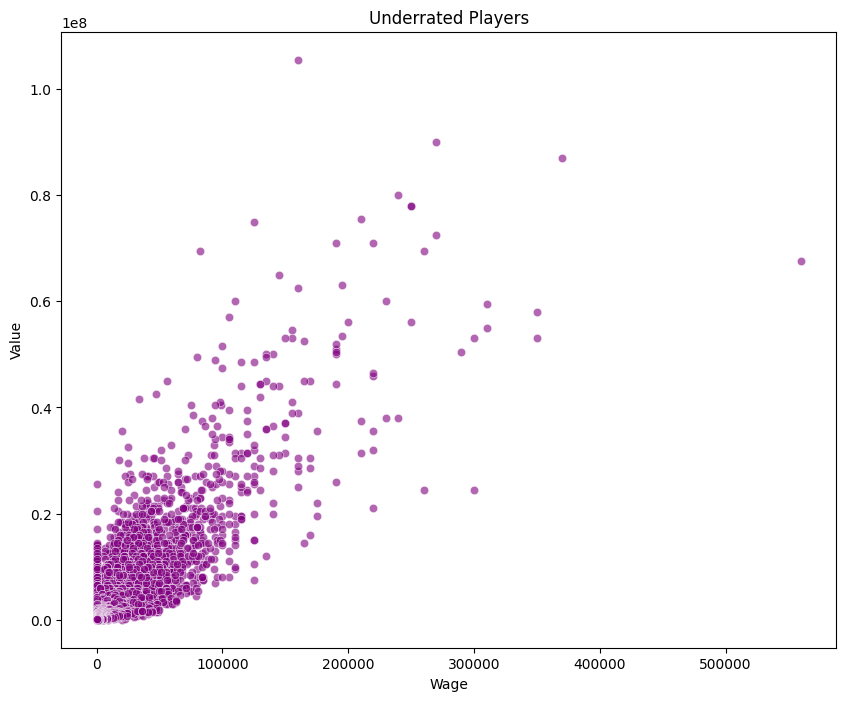

In [22]:
plt.figure(figsize=(10,8))
sns.scatterplot(x = 'Wage', y = 'Value', data = df, alpha = 0.6, color = 'purple')
plt.title('Underrated Players')
plt.xlabel('Wage')
plt.ylabel('Value')
plt.show()

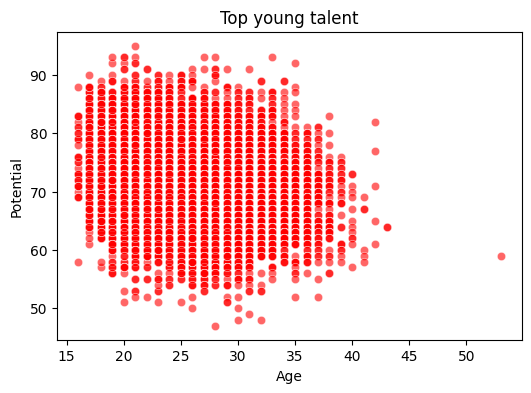

In [23]:
plt.figure(figsize=(6,4))
sns.scatterplot(x = 'Age', y = 'POT', data = df, alpha = 0.6, color = 'Red')
plt.title('Top young talent')
plt.xlabel('Age')
plt.ylabel('Potential')
plt.show()

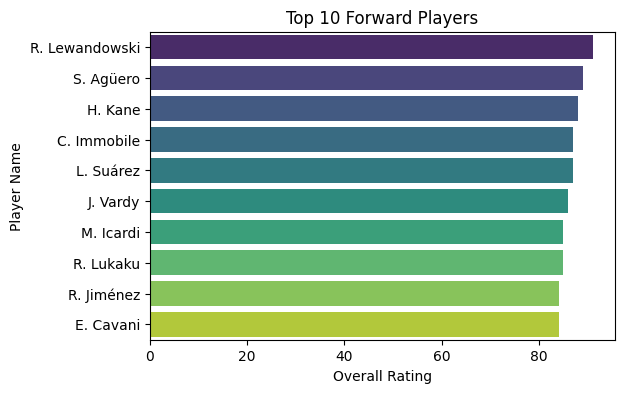

In [24]:
df['Primary Position'] = df['Positions'].apply(lambda x: x.split(',')[0])  # Choose the first position as primary
top_forwards = df[df['Primary Position'] == 'ST'].sort_values(by='OVA', ascending=False).head(10)

plt.figure(figsize=(6,4))
sns.barplot(x = "OVA", y = "Name", data = top_forwards, palette = "viridis")
plt.title('Top 10 Forward Players')
plt.xlabel('Overall Rating')
plt.ylabel('Player Name')
plt.show()

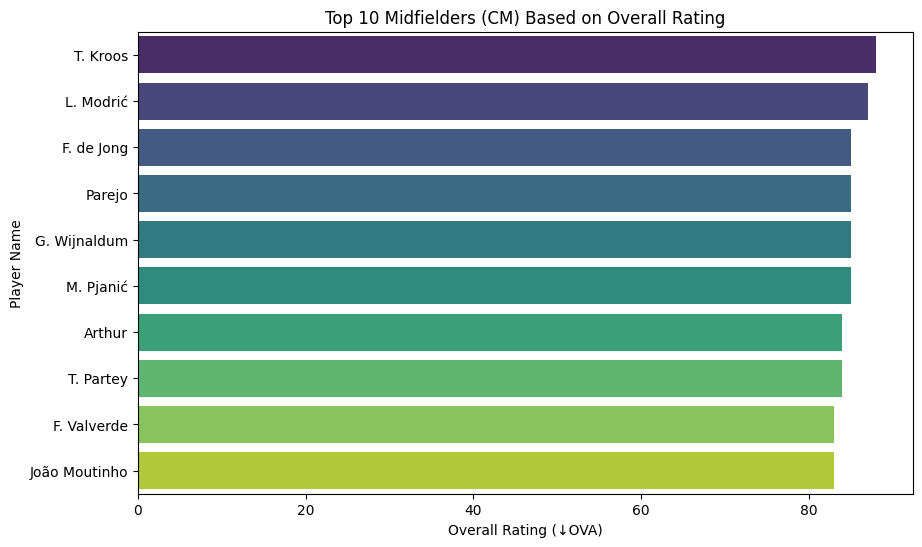

In [25]:
top_midfielders = df[df['Primary Position'] == 'CM'].sort_values(by='OVA', ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x='OVA', y='Name', data=top_midfielders, palette='viridis')
plt.title('Top 10 Midfielders (CM) Based on Overall Rating')
plt.xlabel('Overall Rating (↓OVA)')
plt.ylabel('Player Name')
plt.show()

Text(0.5, 1.0, 'Preferred Foot')

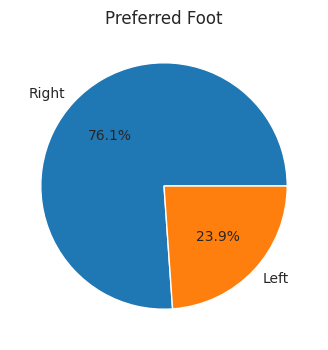

In [26]:
sns.set_style('darkgrid')
plt.figure(figsize=(6,4))
plt.pie(df['foot'].value_counts(), labels = df['foot'].value_counts().index, autopct='%1.1f%%')
plt.title('Preferred Foot')

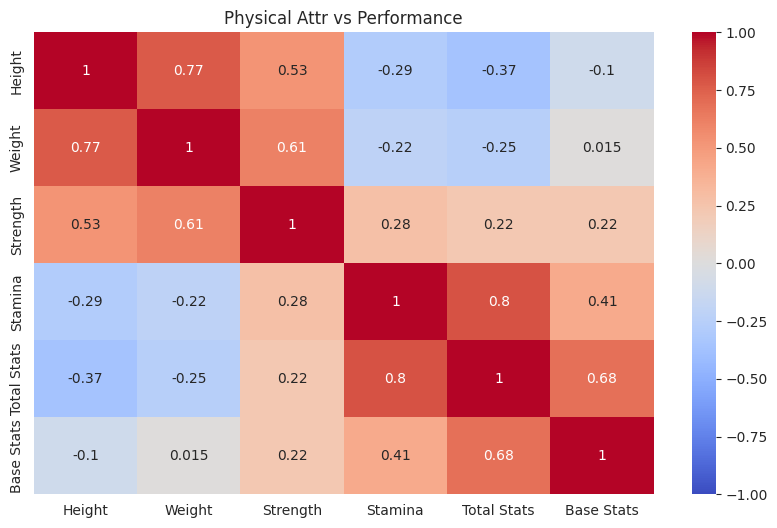

In [27]:
columns_of_interest = ['Height', 'Weight', 'Strength', 'Stamina', 'Total Stats', 'Base Stats']
df_selected = df[columns_of_interest]
correlation_matrix = df_selected.corr()

plt.figure(figsize=(10,6))
sns.heatmap(correlation_matrix, annot = True, cmap = 'coolwarm', vmin = -1, vmax = 1)
plt.title('Physical Attr vs Performance')
plt.show()

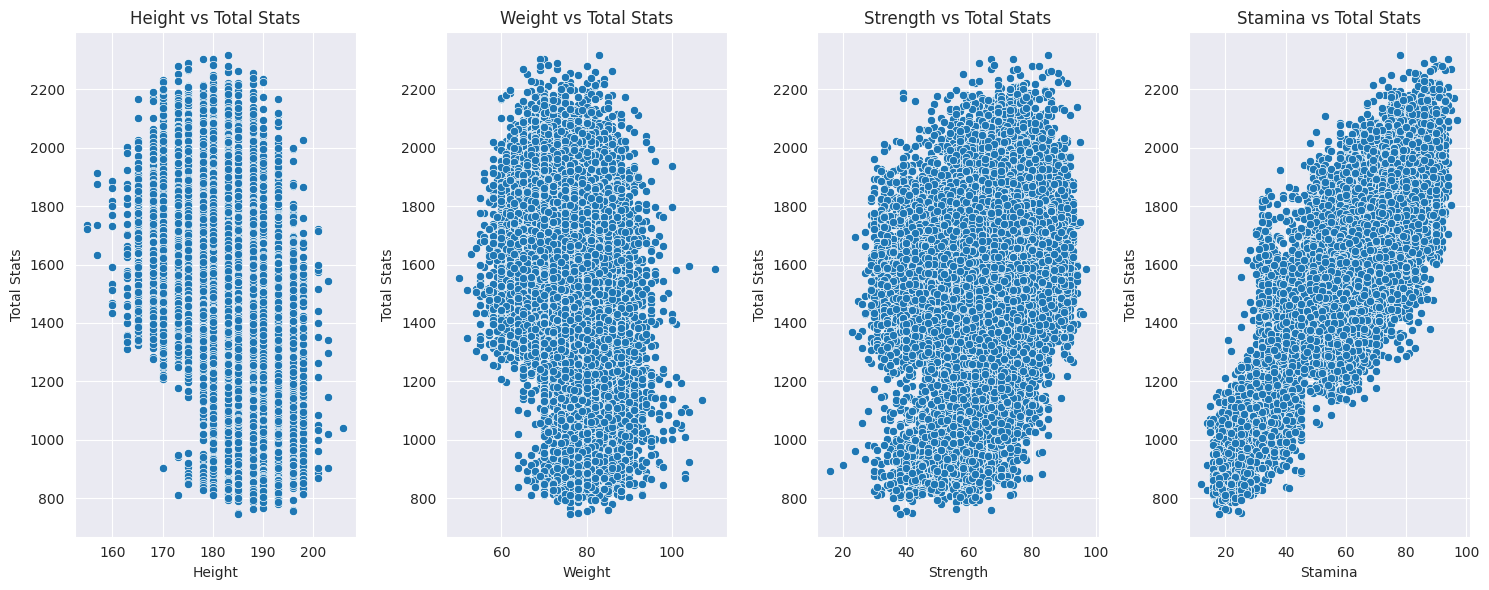

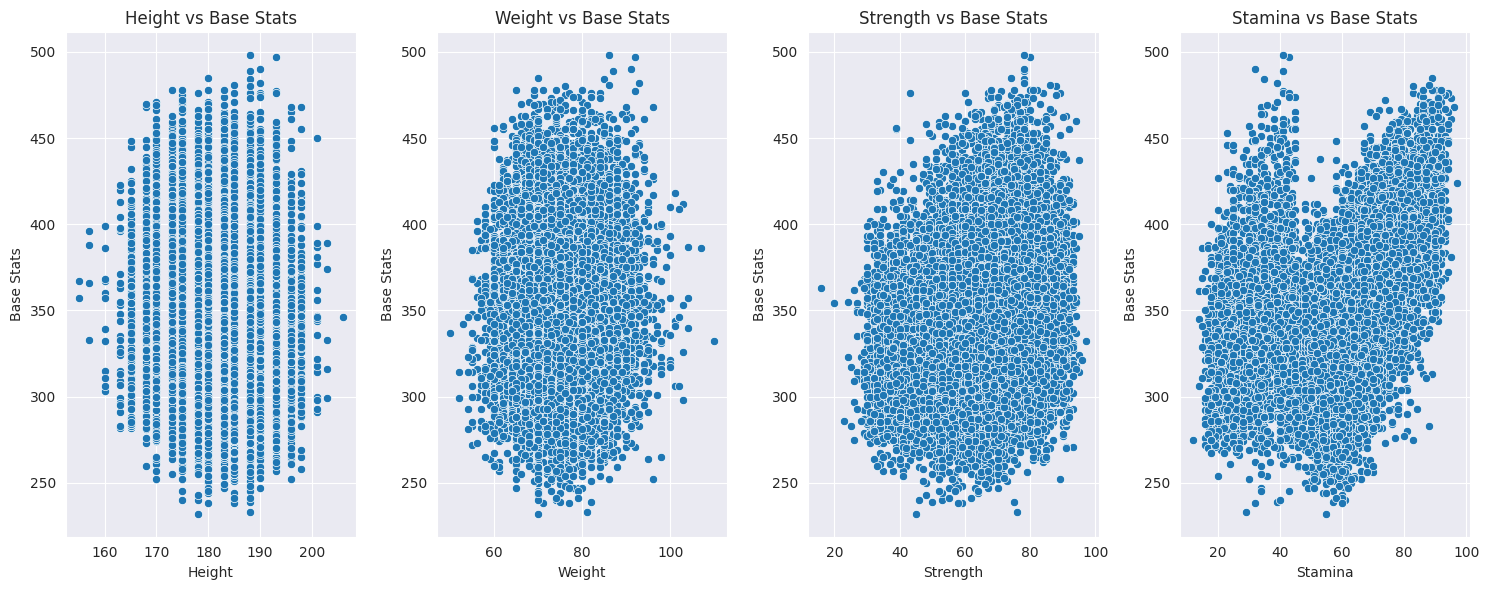

In [28]:
correlations_total_stats = df_selected.corr()['Total Stats']
correlations_base_stats = df_selected.corr()['Base Stats']
plt.figure(figsize=(15, 6))

for i, column in enumerate(['Height', 'Weight', 'Strength', 'Stamina'], 1):
    plt.subplot(1, 4, i)
    sns.scatterplot(data=df_selected, x=column, y='Total Stats')
    plt.title(f'{column} vs Total Stats')
    plt.xlabel(column)
    plt.ylabel('Total Stats')

plt.tight_layout()
plt.show()

# Plot correlations with 'Base Stats'
plt.figure(figsize=(15, 6))

for i, column in enumerate(['Height', 'Weight', 'Strength', 'Stamina'], 1):
    plt.subplot(1, 4, i)
    sns.scatterplot(data=df_selected, x=column, y='Base Stats')
    plt.title(f'{column} vs Base Stats')
    plt.xlabel(column)
    plt.ylabel('Base Stats')

plt.tight_layout()
plt.show()

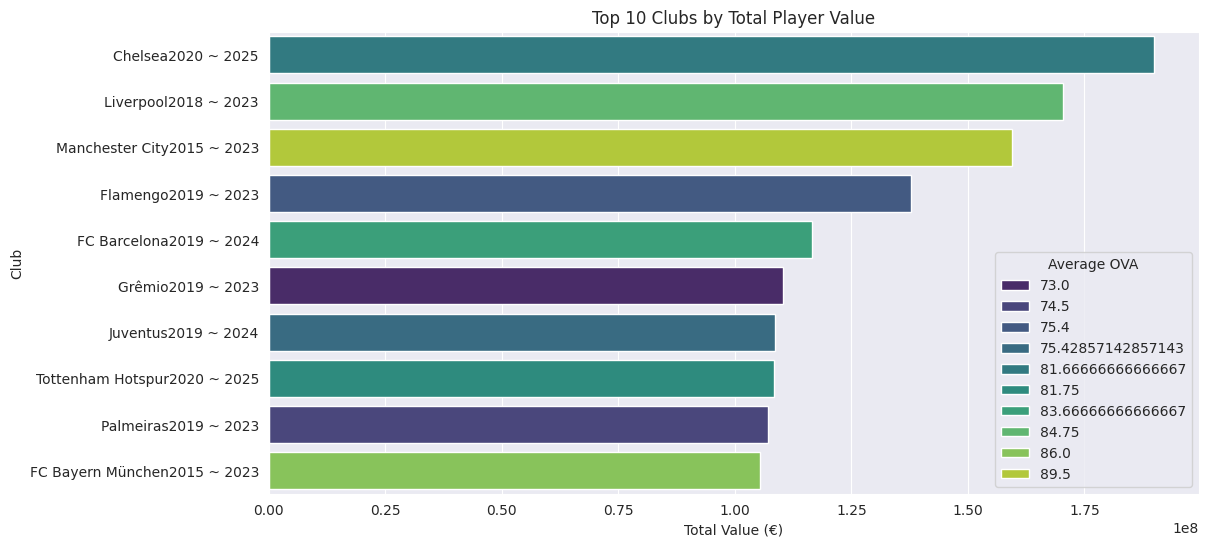

In [29]:
# Group data by Club and calculate total Value, total Wage, and average OVA
club_stats = df.groupby('Club').agg({
    'Value' : 'sum',
    'Wage' : 'sum',
    'OVA' : 'mean' 
}).reset_index()

# Rename columns for clarity
club_stats.rename(columns = {
    'Value' : 'Total Value(€)',
    'Wage' : 'Total Wage(€)',
    'OVA' : 'Average OVA'
}, inplace = True)

# Display the top 10 clubs by Total Value
club_stats.sort_values(by = 'Total Value(€)', ascending = False ).head(10)
top_clubs = club_stats.sort_values(by='Total Value(€)', ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x='Total Value(€)', y='Club', data=top_clubs, palette='viridis', hue='Average OVA', dodge=False)

# Adding titles and labels
plt.title('Top 10 Clubs by Total Player Value')
plt.xlabel('Total Value (€)')
plt.ylabel('Club')
plt.legend(title='Average OVA', loc='lower right')

plt.show()

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


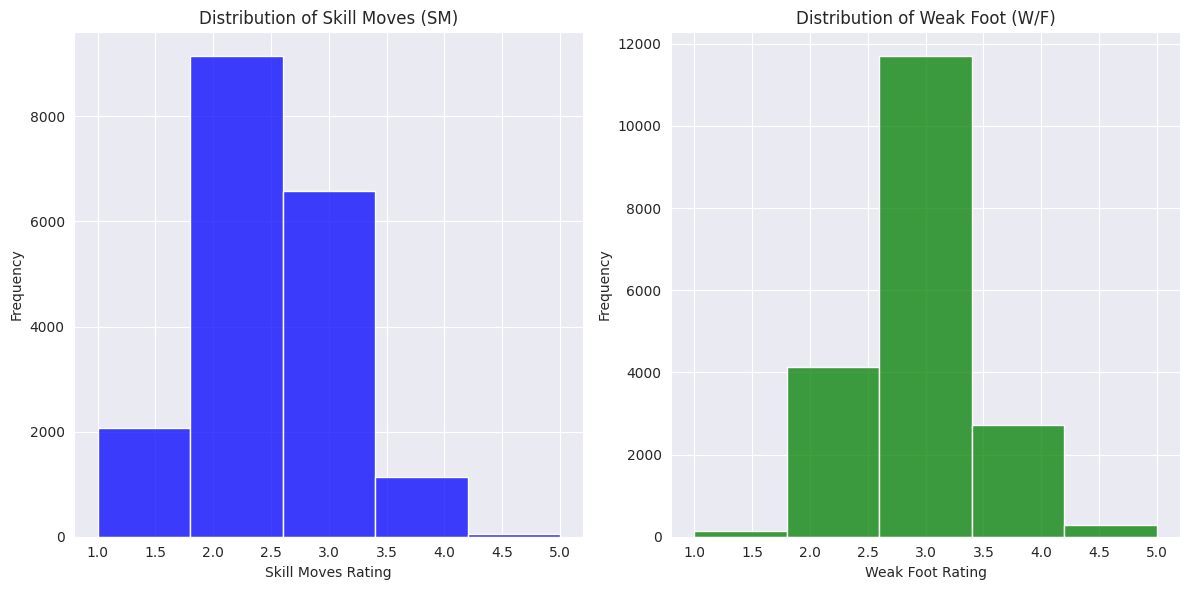

In [30]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.histplot(df['SM'], bins=5, kde=False, color='blue')
plt.title('Distribution of Skill Moves (SM)')
plt.xlabel('Skill Moves Rating')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
sns.histplot(df['W/F'], bins=5, kde=False, color='green')
plt.title('Distribution of Weak Foot (W/F)')
plt.xlabel('Weak Foot Rating')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

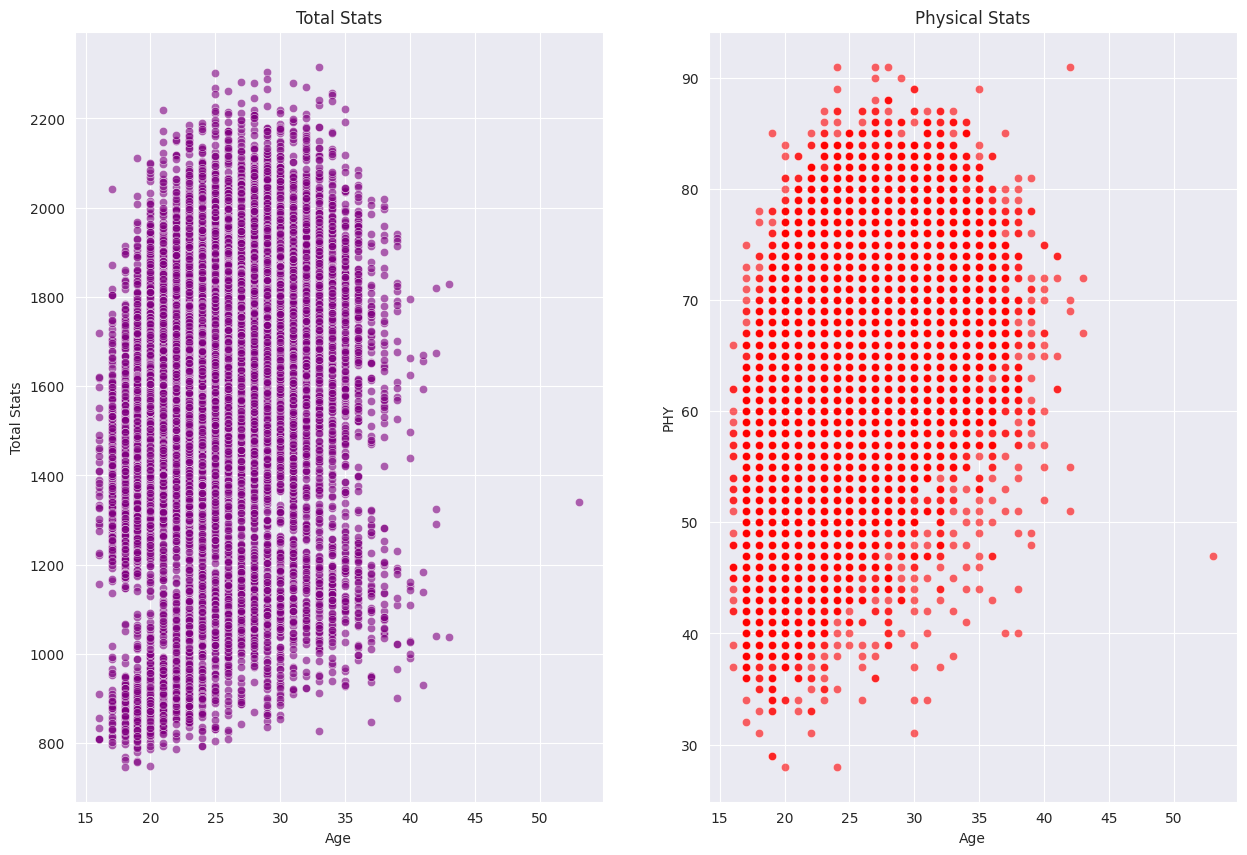

In [31]:
plt.figure(figsize=(15,10))
plt.subplot(1, 2, 1)
sns.scatterplot(x = 'Age', y = 'Total Stats', data = df, alpha = 0.6, color = 'Purple')
plt.title('Total Stats')
plt.xlabel('Age')
plt.ylabel('Total Stats')

plt.subplot(1, 2, 2)
sns.scatterplot(x = 'Age', y = 'PHY', data = df, alpha = 0.6, color = 'Red')
plt.title('Physical Stats')
plt.xlabel('Age')
plt.show()

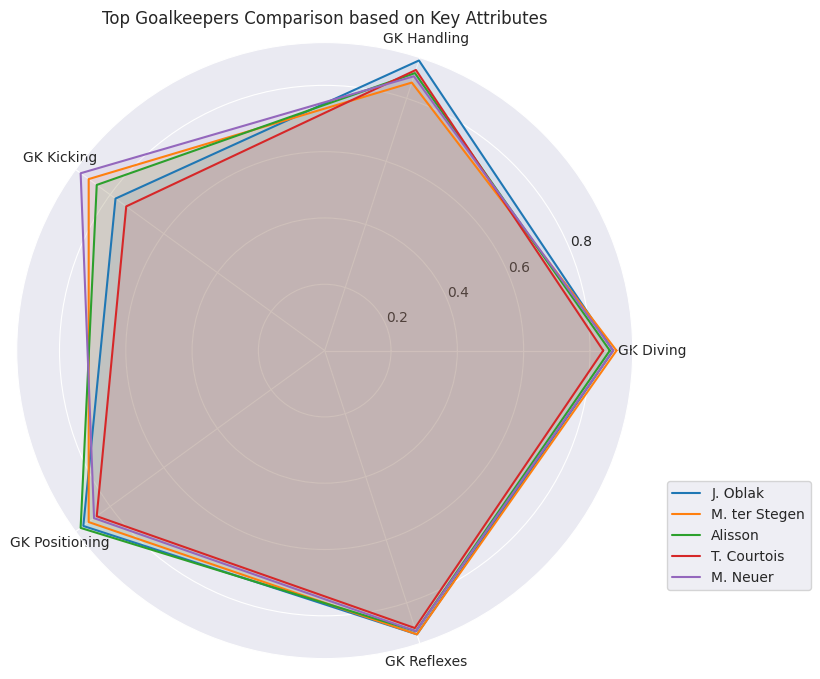

In [32]:
from math import pi

goalkeepers = df[df['Positions'].str.contains('GK')]

# Select relevant columns for goalkeepers
gk_attributes = ['Name', 'OVA', 'GK Diving', 'GK Handling', 'GK Kicking', 'GK Positioning', 'GK Reflexes']
goalkeepers = goalkeepers[gk_attributes]

# Sort goalkeepers by their overall rating and select top N (e.g., top 5)
top_goalkeepers = goalkeepers.sort_values('OVA', ascending=False).head(5)

# Prepare data for radar chart

# Normalize the data to a 0-1 scale for visualization
top_goalkeepers_normalized = top_goalkeepers.copy()
attributes = ['GK Diving', 'GK Handling', 'GK Kicking', 'GK Positioning', 'GK Reflexes']
for attr in attributes:
    top_goalkeepers_normalized[attr] = top_goalkeepers_normalized[attr] / 100

# Plotting radar chart


# Set up the radar chart
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

# Define the angles for the radar chart
categories = attributes
N = len(categories)
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]  # Repeat the first angle to close the circle

# Plot each goalkeeper
for i, row in top_goalkeepers_normalized.iterrows():
    values = row[attributes].tolist()
    values += values[:1]  # Repeat the first value to close the circle
    ax.plot(angles, values, label=row['Name'])
    ax.fill(angles, values, alpha=0.1)

# Add labels and title
ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories)
plt.title('Top Goalkeepers Comparison based on Key Attributes')
plt.legend(loc='lower right', bbox_to_anchor=(1.3, 0.1))

# Show the radar chart
plt.show()